# 1. Setup & credentials

In [ ]:
import os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold, train_test_split

# ---- Analysis parameters ----
CELL_SIZE_DEG = 0.1
EPSG = 4326

# 2. Download earth embedding data

In [ ]:
data_dir = "earth_embeddings_workshop_data"
os.makedirs(data_dir, exist_ok=True)

file = f"{data_dir}.zip"
url = f"https://zenodo.org/record/20140393/files/{file}"
local_zip = f"{data_dir}/{file}"
local_dir = local_zip.replace(".zip", "")

if not os.path.exists(local_dir):
    !wget -O {local_zip} {url}

    !unzip {local_zip} -d {data_dir}

    !rm {local_zip}

!ls -lhR {data_dir}

total 0
drwxr-xr-x  6 cullenmolitor  staff   192B May 12 11:30 earth_embeddings_workshop_data

earth_embeddings_workshop_data/earth_embeddings_workshop_data:
total 0
drwxr-xr-x@  7 cullenmolitor  staff   224B May 11 17:44 features
drwxr-xr-x@ 16 cullenmolitor  staff   512B May 10 21:33 geo_data
drwxr-xr-x@  4 cullenmolitor  staff   128B May 12 09:14 labels
drwxr-xr-x@ 12 cullenmolitor  staff   384B May  9 14:48 planet_basemap_thumbnails

earth_embeddings_workshop_data/earth_embeddings_workshop_data/features:
total 16077904
-rw-r--r--@ 1 cullenmolitor  staff   1.3G May  9 14:07 aef_features_0.01_degree.parquet
-rw-r--r--@ 1 cullenmolitor  staff    16M May  9 14:08 aef_features_0.1_degree.parquet
-rw-r--r--@ 1 cullenmolitor  staff   6.2G May  9 22:36 mosaiks_features_0.01_degree.parquet
-rw-r--r--@ 1 cullenmolitor  staff    86M May  9 23:45 mosaiks_features_0.1_degree.parquet
-rw-r--r--@ 1 cullenmolitor  staff   104M May 10 19:25 mosaiks_features_0.1_degree_api_2019.parquet

earth_embedd

# 3. Load raw GBIF occurrence data for Colorado

In [1]:
filters = [
    ("kingdom", "in", ["Animalia", "Plantae"]),
    ("taxonRank", "==", "SPECIES"),
    ("basisOfRecord", "==", "HUMAN_OBSERVATION"),
]

USE_COLS = [
    "gbifID",
    "kingdom",
    # "phylum",
    # "class",
    # "order",
    # "family",
    # "genus",
    "species",
    "taxonRank",
    # "scientificName",
    "individualCount",
    "decimalLatitude",
    "decimalLongitude",
    "coordinateUncertaintyInMeters",
    # "elevation",
    # "elevationAccuracy",
    "year",
    "basisOfRecord",
]

occurrence_fp = os.path.join(local_dir, "labels", "colorado_occurrence_2016-2025.parquet")
occurrence_df = pd.read_parquet(
    path=occurrence_fp,
    engine="pyarrow",
    columns=USE_COLS,
    filters=filters,
).dropna(subset=["species", "decimalLatitude", "decimalLongitude"])

occurrence_df.head()

NameError: name 'os' is not defined

# 4. Clean records

Standard hygiene before diversity stats:
- Drop rows with missing species, year, or coords
- Keep records identified at species rank (drops genus-only / family-only)
- Drop records with very high coordinate uncertainty (> 5 km) — these can't be sensibly assigned to a 1 km cell

In [ ]:
occurrence_df.kingdom.value_counts()

kingdom
Animalia          23847472
Plantae             506220
Bacteria                 0
Chromista                0
Fungi                    0
Protozoa                 0
Viruses                  0
incertae sedis           0
Name: count, dtype: int64

In [ ]:
occurrence_df.taxonRank.value_counts()

taxonRank
SPECIES       24353692
CLASS                0
FAMILY               0
FORM                 0
GENUS                0
KINGDOM              0
ORDER                0
PHYLUM               0
SUBSPECIES           0
UNRANKED             0
VARIETY              0
Name: count, dtype: int64

In [ ]:
occurrence_df.basisOfRecord.value_counts()

basisOfRecord
HUMAN_OBSERVATION      24353692
MACHINE_OBSERVATION           0
MATERIAL_SAMPLE               0
PRESERVED_SPECIMEN            0
Name: count, dtype: int64

In [ ]:
# occurrence_df.year.value_counts()
occurrence_df.individualCount.value_counts()

individualCount
1.0        8124059
2.0        4683352
3.0        2108175
4.0        1612424
5.0        1018784
            ...   
1476.0           1
10400.0          1
2790.0           1
2027.0           1
1885.0           1
Name: count, Length: 1807, dtype: int64

In [ ]:
df_clean = occurrence_df.copy()

df_clean = df_clean[df_clean["kingdom"].isin(["Animalia"])]

df_clean = df_clean.dropna(
    subset=["species", "year", "decimalLatitude", "decimalLongitude"]
)

# Coordinate uncertainty filter (NaN means unknown — keep)
df_clean = df_clean[
    (df_clean["coordinateUncertaintyInMeters"].isna())
    | (df_clean["coordinateUncertaintyInMeters"] <= 5000)
]

print(f"Clean data N: {len(df_clean):,}")
print(f"Rows dropped: ({len(occurrence_df) - len(df_clean):,})")
print(f"Unique species: {df_clean['species'].nunique():,}")
print(f"Year range:    {df_clean['year'].min()}–{df_clean['year'].max()}")

Clean data N: 23,802,673
Rows dropped: (551,019)
Unique species: 5,588
Year range:    2016–2025


# 5. Snap occurrences to the grid

Round each occurrence's coordinates to the nearest grid-cell center so the table joins cleanly onto the features later (which use the same convention).

This is far simpler than trying to assign each occurrence to a cell polygon or similar. The grid is regular and the cell centers are at nice round numbers (e.g. 36.895, 36.905, 36.915, ...), so we can just round the lat/lon to the nearest center.

In [ ]:
def snap(x, res=CELL_SIZE_DEG):
    inv = round(1 / res)  # e.g. 100 for 0.01°
    return (np.floor(x * inv) + 0.5) / inv


df_clean["lat"] = snap(df_clean["decimalLatitude"])
df_clean["lon"] = snap(df_clean["decimalLongitude"])

df_clean[["decimalLatitude", "decimalLongitude", "lat", "lon"]].head()

,decimalLatitude,decimalLongitude,lat,lon
0,38.016570,-108.115521,38.05,-108.15
1,38.948933,-104.886368,38.95,-104.85
3,40.595807,-104.983482,40.55,-104.95
4,39.492175,-105.696423,39.45,-105.65
5,39.197126,-106.139342,39.15,-106.15


# 6. Compute Shannon diversity per (year, cell)

Shannon index using natural log:

$$H' = -\sum_{i=1}^{S} p_i \ln p_i$$

where $p_i = n_i / N$ is the proportion of occurrences belonging to species $i$ in that cell-year. We compute it via groupby in one vectorized pass.

In [ ]:
# Step A: count occurrences per (year, cell, species)
counts = (
    df_clean.groupby(["year", "lat", "lon", "species"], observed=True)
    .size()
    .rename("n")
    .reset_index()
)

# Step B: total occurrences per (year, cell)
totals = (
    counts.groupby(["year", "lat", "lon"], observed=True)["n"]
    .sum()
    .rename("N")
    .reset_index()
)

# Step C: proportions and -p*ln(p), summed per cell-year
counts = counts.merge(totals, on=["year", "lat", "lon"])
counts["p"] = counts["n"] / counts["N"]
counts["plnp"] = -counts["p"] * np.log(counts["p"])

shannon = (
    counts.groupby(["year", "lat", "lon"], observed=True)
    .agg(
        shannon_H=("plnp", "sum"),
        species_richness=("species", "nunique"),
        n_occ=("n", "sum"),
    )
    .reset_index()
)

# Pielou's evenness J' = H' / ln(S) (NaN when S=1)
with np.errstate(divide="ignore", invalid="ignore"):
    shannon["pielou_J"] = shannon["shannon_H"] / np.log(shannon["species_richness"])
shannon.loc[shannon["species_richness"] <= 1, "pielou_J"] = np.nan

shannon = shannon[shannon.n_occ >= 10]

shannon.head()

,year,lat,lon,shannon_H,species_richness,n_occ,pielou_J
1,2016,36.95,-105.95,1.557113,5,10,0.967489
2,2016,36.95,-105.65,2.995732,20,20,1.000000
4,2016,36.95,-104.35,3.163424,24,25,0.995397
5,2016,37.05,-109.05,3.126343,28,76,0.938221
6,2016,37.05,-108.75,3.193437,28,47,0.958356


# 8. Map mean Shannon H' per cell

Same plotting recipe as the MOSAIKS feature map below: build a GeoDataFrame of
square cell polygons centered on each `(lat, lon)`, then plot the mean H' over
all years.


/var/folders/sn/h82qf8ws0016_fgmpp88gfhc0000gn/T/ipykernel_88610/2512188712.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cell_mean_gdf.geometry = cell_mean_gdf.buffer(CELL_SIZE_DEG / 2, cap_style=3)


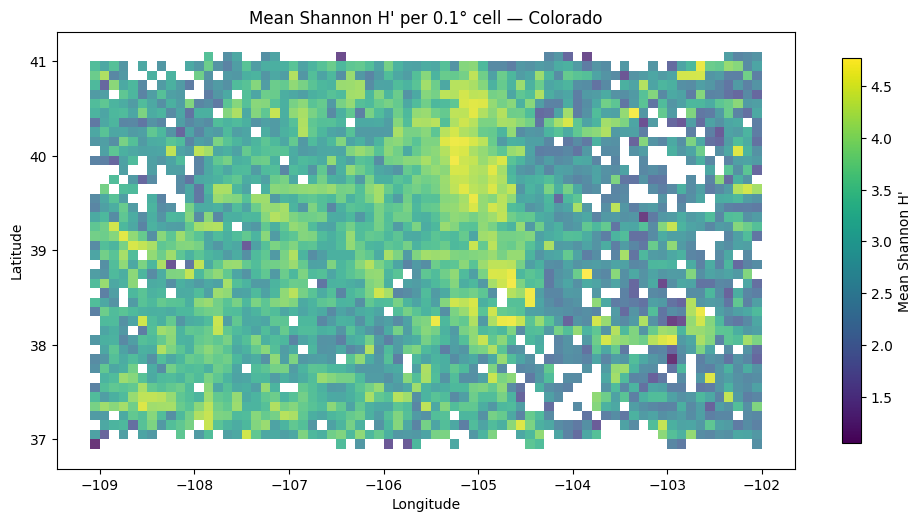

In [ ]:
# Mean H' per cell across all years
cell_mean = shannon.groupby(["lat", "lon"], as_index=False)["shannon_H"].mean()

# Build square cell polygons centered on (lat, lon)
cell_mean_gdf = gpd.GeoDataFrame(
    cell_mean,
    geometry=gpd.points_from_xy(x=cell_mean.lon, y=cell_mean.lat),
    crs=EPSG,
)
cell_mean_gdf.geometry = cell_mean_gdf.buffer(CELL_SIZE_DEG / 2, cap_style=3)

fig, ax = plt.subplots(figsize=(10, 8))
cell_mean_gdf.plot(
    ax=ax,
    column="shannon_H",
    cmap="viridis",
    alpha=0.8,
    legend=True,
    legend_kwds={"label": "Mean Shannon H'", "shrink": 0.5},
)
# colorado.boundary.plot(ax=ax, color="red", linewidth=1.5)

ax.set_title(f"Mean Shannon H' per {CELL_SIZE_DEG}° cell — Colorado")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

# 9. Load MOSAIKS features for Colorado

In [ ]:
out_path = os.path.join(
    local_dir, "features", f"mosaiks_features_{CELL_SIZE_DEG}_degree.parquet"
)

mosaiks_feats = pd.read_parquet(out_path)
print(f"Loaded {len(mosaiks_feats):,} rows → {out_path}")
mosaiks_feats

Loaded 29,820 rows → earth_embeddings_workshop_data/earth_embeddings_workshop_data/features/mosaiks_features_0.1_degree.parquet


,year,lat,lon,unique_id,X_0,X_1,X_2,X_3,X_4,X_5,...,X_502,X_503,X_504,X_505,X_506,X_507,X_508,X_509,X_510,X_511
0,2016,36.95,-109.05,lon_-109.05__lat_36.95,0.234120,0.302911,0.019021,0.553064,0.231169,0.169970,...,0.896197,0.491553,0.237996,1.295897,0.064729,0.057647,0.259235,0.075551,0.105668,0.254053
1,2016,36.95,-108.95,lon_-108.95__lat_36.95,0.326275,0.292471,0.034289,0.641519,0.256354,0.163321,...,0.972628,0.552636,0.265280,1.288121,0.096267,0.080661,0.303635,0.099820,0.132544,0.257028
2,2016,36.95,-108.85,lon_-108.85__lat_36.95,0.173979,0.141610,0.017923,0.429491,0.103138,0.083111,...,0.787072,0.421967,0.263495,0.986545,0.140102,0.104970,0.281061,0.144071,0.159798,0.203109
3,2016,36.95,-108.75,lon_-108.75__lat_36.95,0.250770,0.181070,0.068145,0.463949,0.165117,0.088824,...,0.847272,0.418489,0.270596,0.958315,0.155332,0.158130,0.306728,0.135112,0.167878,0.223641
4,2016,36.95,-108.65,lon_-108.65__lat_36.95,0.644518,0.559226,0.111578,0.954700,0.547835,0.288428,...,1.077350,0.585927,0.265769,1.226110,0.060816,0.072840,0.299436,0.035088,0.120103,0.255480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29815,2025,41.05,-102.45,lon_-102.45__lat_41.05,0.645599,0.680771,0.273441,0.442471,0.903015,0.128303,...,1.369621,1.102464,0.633139,2.094591,0.330908,0.364881,0.583986,0.404258,0.381292,0.801973
29816,2025,41.05,-102.35,lon_-102.35__lat_41.05,1.047286,0.856487,0.579817,0.588054,1.275008,0.146937,...,1.580432,1.082887,0.695666,2.166797,0.418403,0.596055,0.713397,0.391595,0.454509,0.880006
29817,2025,41.05,-102.25,lon_-102.25__lat_41.05,1.288798,0.848275,1.098170,0.505200,1.498338,0.156082,...,1.686263,0.825683,0.864649,1.593182,0.797205,1.280238,1.105991,0.548470,0.796679,1.096955
29818,2025,41.05,-102.15,lon_-102.15__lat_41.05,0.942761,0.679236,0.773379,0.408845,1.087443,0.126763,...,1.398971,0.738385,0.723029,1.373677,0.636712,0.964507,0.879582,0.473910,0.650244,0.889185


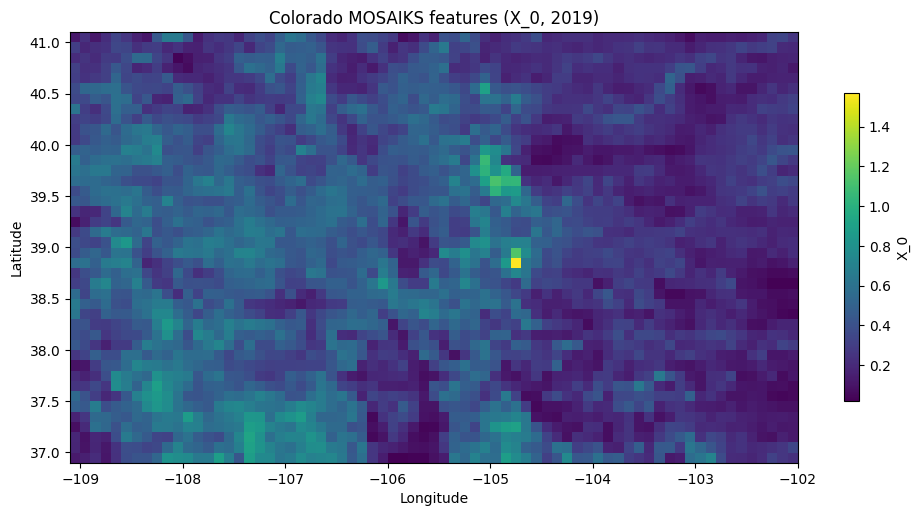

In [ ]:
column_to_plot = "X_0"
year_to_plot = 2019
df = mosaiks_feats.copy()
df = df[df.year == year_to_plot]

# Build the grid axes from unique coords (sorted)
lons = np.sort(df.lon.unique())
lats = np.sort(df.lat.unique())

# Map each row to its (i, j) index in the grid
lon_idx = np.searchsorted(lons, df.lon.values)
lat_idx = np.searchsorted(lats, df.lat.values)

# Allocate raster, fill with NaN for missing cells, then scatter values in
raster = np.full((len(lats), len(lons)), np.nan, dtype=np.float32)
raster[lat_idx, lon_idx] = df[column_to_plot].values

# Compute extent for imshow (pixel edges, not centers)
half = CELL_SIZE_DEG / 2
extent = [lons.min() - half, lons.max() + half, lats.min() - half, lats.max() + half]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(
    raster,
    extent=extent,
    origin="lower",  # because lats are sorted ascending
    cmap="viridis",
    interpolation="nearest",
)
plt.colorbar(im, ax=ax, label=column_to_plot, shrink=0.4)
ax.set_title(f"Colorado MOSAIKS features ({column_to_plot}, {year_to_plot})")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

# 10. Predict Shannon H' from MOSAIKS features

Quick supervised baseline:

1. Average H' across years per cell so the label aligns with the single-year (2019) MOSAIKS features
2. Inner-join labels onto features by `(lat, lon)`
3. Hold out 20% as a test set
4. 5-fold CV ridge regression (sweep alpha) on the train set
5. Refit on the full train set with the best alpha and evaluate on the test set


Merged dataset: 17,550 cells


/Users/cullenmolitor/Documents/github/MOSAIKS-Training-Manual/.venv/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.145053437795923e-10.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/cullenmolitor/Documents/github/MOSAIKS-Training-Manual/.venv/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.0044239601446634e-09.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/cullenmolitor/Documents/github/MOSAIKS-Training-Manual/.venv/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.785219301505776e-10.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/cullenmolitor/Documents/github/MOSAIKS-Training-Manual/.venv/lib/python3.11/site-packages/sklearn/linear_model/_ridg

Best alpha: 0.1
Test R²: 0.205


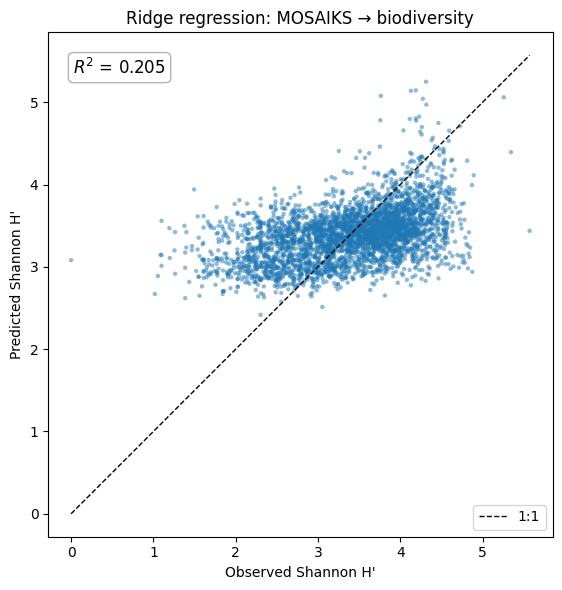

In [ ]:
mosaiks = mosaiks_feats.copy()
labels = shannon.copy()

merged = mosaiks.merge(labels, on=["lat", "lon", "year"], how="inner")
print(f"Merged dataset: {len(merged):,} cells")

X_cols = [c for c in merged.columns if c.startswith("X_")]
X = merged[X_cols].values
y = merged["shannon_H"].values

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 5-fold CV ridge ---
alphas = np.logspace(-1, 4, 20)
ridge = RidgeCV(alphas=alphas, cv=KFold(n_splits=5, shuffle=True, random_state=42))
ridge.fit(X_train, y_train)
print(f"Best alpha: {ridge.alpha_:.3g}")

# --- Evaluate on the held-out test set ---
y_pred = ridge.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"Test R²: {r2:.3f}")

# --- Plot predicted vs. observed scatter with 1:1 line ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, s=10, alpha=0.5, edgecolor="none")

lo = min(y_test.min(), y_pred.min())
hi = max(y_test.max(), y_pred.max())
ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, label="1:1")

ax.text(
    0.05,
    0.95,
    f"$R^2$ = {r2:.3f}",
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.7"),
)

ax.set_xlabel("Observed Shannon H'")
ax.set_ylabel("Predicted Shannon H'")
ax.set_title("Ridge regression: MOSAIKS → biodiversity")
ax.set_aspect("equal")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 11. Load AEF (Annual Embedding Features) for Colorado

The AEF files are 64-dimensional satellite embeddings from 2017 and 2018,
stored as 8 CSV files split by year and quadrant (NE/NW/SE/SW).
We read all 8, concatenate them, then average the two years per cell so each
`(lat, lon)` has a single 64-dim vector — the same spatial aggregation used for
the Shannon labels.

In [ ]:
out_path = os.path.join(local_dir, "features", f"aef_features_{CELL_SIZE_DEG}_degree.parquet")

aef_feats = pd.read_parquet(out_path)
print(f"Loaded {len(aef_feats):,} rows → {out_path}")
aef_feats

Loaded 26,838 rows → earth_embeddings_workshop_data/earth_embeddings_workshop_data/features/aef_features_0.1_degree.parquet


,region,lon,lat,unique_id,year,A00,A01,A02,A03,A04,...,A54,A55,A56,A57,A58,A59,A60,A61,A62,A63
0,colorado,-109.05,38.95,co_001491,2022,0.096269,0.010707,-0.086997,-0.135008,0.093216,...,0.146216,0.049863,-0.203000,-0.148282,-0.047784,0.008612,0.014492,0.024965,0.095226,-0.017903
1,colorado,-108.95,38.95,co_001492,2022,0.089767,-0.036495,-0.085625,-0.107567,0.093965,...,0.157076,0.048295,-0.187825,-0.128851,-0.058739,-0.030455,0.009488,0.057216,0.065097,-0.008333
2,colorado,-108.85,38.95,co_001493,2022,0.091877,-0.038072,-0.059630,-0.113671,0.086611,...,0.166887,0.047340,-0.212195,-0.133957,-0.048760,-0.024385,0.008054,0.042744,0.047241,0.009871
3,colorado,-108.75,38.95,co_001494,2022,0.067342,-0.052519,-0.082379,-0.093829,0.100639,...,0.158503,0.057330,-0.195995,-0.150036,-0.050286,-0.009866,0.003441,0.050151,0.047301,0.001289
4,colorado,-108.65,38.95,co_001495,2022,0.105322,-0.046321,-0.078567,-0.109746,0.078320,...,0.160245,0.029932,-0.202374,-0.111142,-0.053579,-0.040021,-0.002420,0.028206,0.019008,-0.007661
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26833,colorado,-106.05,39.05,co_001450,2022,0.045079,-0.221694,0.006978,-0.141225,-0.058116,...,0.152155,0.008984,-0.250859,-0.164879,-0.047029,-0.008877,-0.093598,0.125294,-0.009396,-0.015274
26834,colorado,-105.95,39.05,co_001451,2022,0.055521,-0.254835,0.015241,-0.108792,0.025964,...,0.116079,0.035496,-0.322536,-0.240938,-0.055097,0.033760,-0.064198,0.146387,0.004565,0.060842
26835,colorado,-105.85,39.05,co_001452,2022,0.041540,-0.253576,0.024512,-0.095844,0.027357,...,0.136683,0.031295,-0.321150,-0.231018,-0.061913,0.038868,-0.053760,0.134445,-0.001275,0.055916
26836,colorado,-105.75,39.05,co_001453,2022,0.023754,-0.275060,0.034137,-0.081519,0.020517,...,0.141259,0.004322,-0.324119,-0.203323,-0.096236,0.040168,-0.055356,0.117809,-0.033894,0.024530


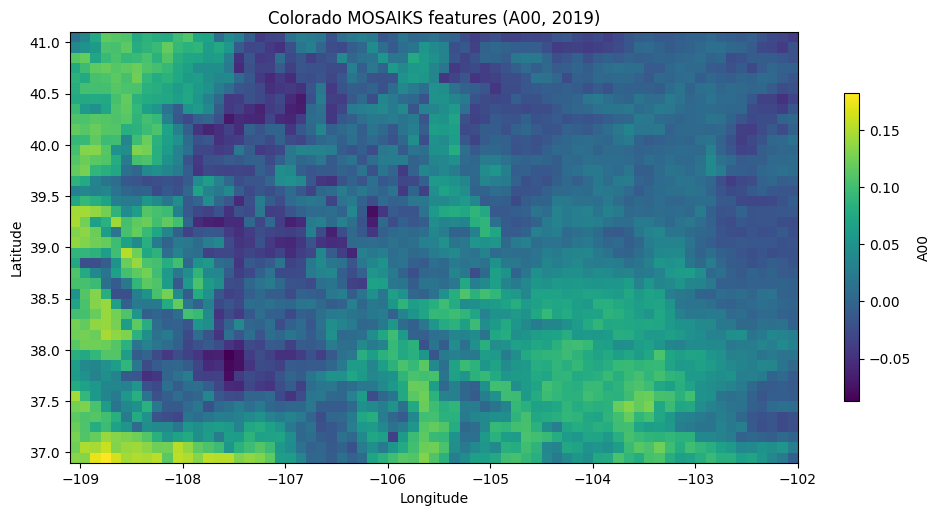

In [ ]:
column_to_plot = "A00"
year_to_plot = 2019
df = aef_feats.copy()
df = df[df.year == year_to_plot]

# Build the grid axes from unique coords (sorted)
lons = np.sort(df.lon.unique())
lats = np.sort(df.lat.unique())

# Map each row to its (i, j) index in the grid
lon_idx = np.searchsorted(lons, df.lon.values)
lat_idx = np.searchsorted(lats, df.lat.values)

# Allocate raster, fill with NaN for missing cells, then scatter values in
raster = np.full((len(lats), len(lons)), np.nan, dtype=np.float32)
raster[lat_idx, lon_idx] = df[column_to_plot].values

# Compute extent for imshow (pixel edges, not centers)
half = CELL_SIZE_DEG / 2
extent = [lons.min() - half, lons.max() + half, lats.min() - half, lats.max() + half]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(
    raster,
    extent=extent,
    origin="lower",  # because lats are sorted ascending
    cmap="viridis",
    interpolation="nearest",
)
plt.colorbar(im, ax=ax, label=column_to_plot, shrink=0.4)
ax.set_title(f"Colorado MOSAIKS features ({column_to_plot}, {year_to_plot})")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

# 12. Predict Shannon H' from AEF features

Same pipeline as Section 10 — RidgeCV with 5-fold CV, identical train/test split
(`random_state=42`) — so the R² values are directly comparable.
At the end we place both scatter plots side by side for a visual comparison.

Merged dataset: 15,896 cells
Best alpha: 0.1
Test R² (AEF,  64 features): 0.312
Test R² (MOSAIKS, 512 features): 0.205


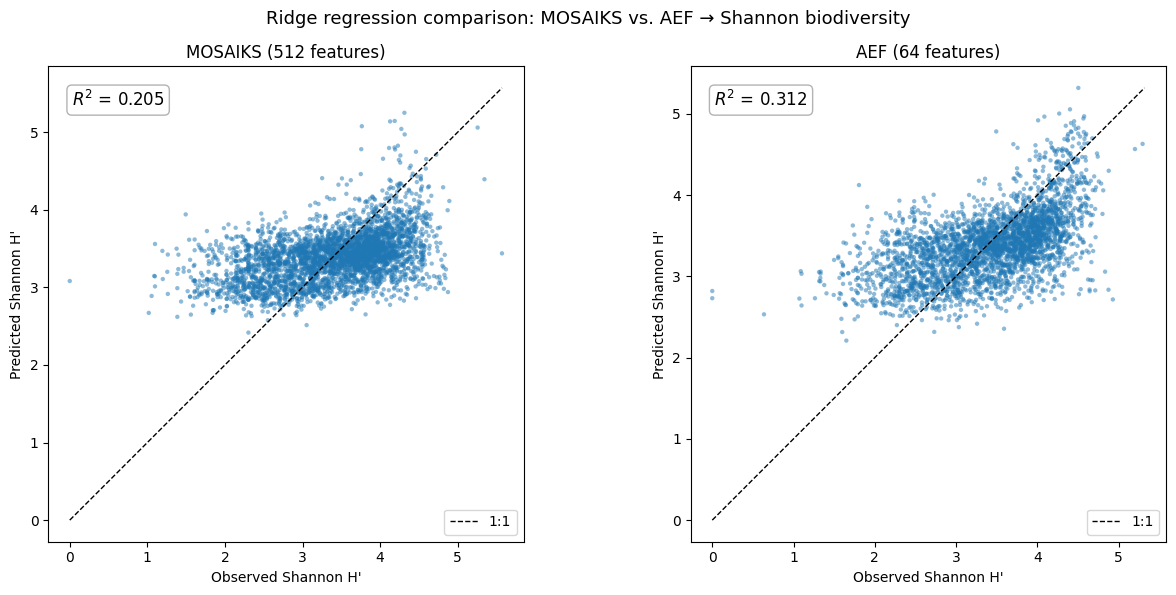

In [ ]:
# --- 1. Join AEF features to the same labels ---
aef = aef_feats.copy()
labels = shannon.copy()

merged_aef = aef.merge(labels, on=["lat", "lon", "year"], how="inner")

# merged_aef = merged_aef.dropna(subset=["pielou_J"])

print(f"Merged dataset: {len(merged_aef):,} cells")

A_cols = [c for c in merged_aef.columns if c.startswith("A")]
X_aef = merged_aef[A_cols].values
# shannon_H, n_occ, pielou_J
y_aef = merged_aef["shannon_H"].values


# --- 2. Identical train/test split ---
X_aef_train, X_aef_test, y_aef_train, y_aef_test = train_test_split(
    X_aef, y_aef, test_size=0.2, random_state=42
)

# --- 3. 5-fold CV ridge (same alpha grid) ---
ridge_aef = RidgeCV(alphas=alphas, cv=KFold(n_splits=5, shuffle=True, random_state=42))
ridge_aef.fit(X_aef_train, y_aef_train)
print(f"Best alpha: {ridge_aef.alpha_:.3g}")

# --- 4. Evaluate ---
y_aef_pred = ridge_aef.predict(X_aef_test)
r2_aef = r2_score(y_aef_test, y_aef_pred)
print(f"Test R² (AEF,  64 features): {r2_aef:.3f}")
print(f"Test R² (MOSAIKS, 512 features): {r2:.3f}")

# --- 5. Side-by-side scatter plots ---
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, y_obs, y_hat, r2_val, title in [
    (axes[0], y_test, y_pred, r2, "MOSAIKS (512 features)"),
    (axes[1], y_aef_test, y_aef_pred, r2_aef, "AEF (64 features)"),
]:
    ax.scatter(y_obs, y_hat, s=10, alpha=0.5, edgecolor="none")
    lo = min(y_obs.min(), y_hat.min())
    hi = max(y_obs.max(), y_hat.max())
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, label="1:1")
    ax.text(
        0.05,
        0.95,
        f"$R^2$ = {r2_val:.3f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=12,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.7"),
    )
    ax.set_xlabel("Observed Shannon H'")
    ax.set_ylabel("Predicted Shannon H'")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.legend(loc="lower right")

fig.suptitle(
    "Ridge regression comparison: MOSAIKS vs. AEF → Shannon biodiversity", fontsize=13
)
plt.tight_layout()
plt.show()